# Analyze dataset quality across splits

Produce a comprehensive quality report across dataset splits using the config-driven
`data-analysis` workflow.

## What you'll do

- Download the CPPE-5 dataset from HuggingFace and prepare it as a multi-split dataset
- Build a workflow configuration for multi-split analysis
- Run the `data-analysis` workflow via `run_task()`
- View the built-in **analysis report** for a high-level summary of all assessment areas
- Explore cross-split comparisons — label overlap, duplicate leakage, and distribution parity
- Configure **health thresholds** to control when findings trigger warnings
- Export results to JSON for downstream tooling

## What you'll learn

- How to configure and run the `data-analysis` workflow via `run_task()`
- How to read the built-in **analysis report** (`result.report()`) for a quick summary
- What the five assessment areas cover: image quality, redundancy, label health, bias, and
  cross-split comparisons
- How to configure **health thresholds** to control warning severity
- The difference between **advisory** mode (report only) and **preparatory** mode

## What you'll need

- `dataeval-flow` (includes `dataeval`, `datasets`, `maite-datasets`, `pydantic`)
- Internet connection (to download CPPE-5 from HuggingFace Hub on first run)

### Step-by-step guide

## Data Preparation: Load and prepare the dataset

Download [CPPE-5](https://huggingface.co/datasets/rishitdagli/cppe-5) from HuggingFace and
save it to disk. CPPE-5 is a small (~1.5K images) object detection dataset for medical
personal protective equipment with 5 classes (Coverall, Face Shield, Gloves, Goggles, Mask).
It ships with `train` and `test` splits, making it ideal for demonstrating cross-split analysis.

In [1]:
from datasets import load_dataset as hf_load

# Download CPPE-5 from HuggingFace (train + test splits)
cppe5 = hf_load("rishitdagli/cppe-5")
print(f"Splits: {list(cppe5.keys())}")
for name, ds in cppe5.items():
    print(f"  {name}: {len(ds)} images")

/home/aweng/2033/dataeval-flow/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Splits: ['train', 'test']
  train: 1000 images
  test: 29 images


In [2]:
from pathlib import Path

# Save to disk in HuggingFace arrow format
data_path = Path("./data/cppe5")
cppe5.save_to_disk(str(data_path))
print(f"Saved to {data_path}")

Saving the dataset (1/1 shards): 100%|██████████| 29/29 [00:00<00:00, 4682.22 examples/s]

Saved to data/cppe5


## Step 1: Build the workflow configuration

The `data-analysis` workflow requires explicit parameters (no hidden defaults). We'll
configure outlier detection using **z-score** thresholding across dimension, pixel, and
visual statistics, and enable **balance** and **diversity** analysis to surface metadata
bias signals.

Health thresholds control when findings are elevated to warnings. We relax several
thresholds because CPPE-5 is a diverse object-detection dataset where moderate outlier
rates and class imbalance are expected.

In [3]:
from dataeval.config import set_max_processes

from dataeval_flow.config import (
    DataAnalysisTaskConfig,
    DataAnalysisWorkflowConfig,
    HuggingFaceDatasetConfig,
    PipelineConfig,
    SelectionConfig,
    SelectionStep,
    SourceConfig,
)
from dataeval_flow.workflow import run_task
from dataeval_flow.workflows.analysis.params import DataAnalysisHealthThresholds

set_max_processes(8)

analysis_workflow = DataAnalysisWorkflowConfig(
    name="cppe5_analysis",
    outlier_method="adaptive",
    outlier_flags=["dimension", "pixel", "visual"],
    outlier_threshold=4.0,
    balance=True,
    diversity_method="simpson",
    include_image_stats=True,
    health_thresholds=DataAnalysisHealthThresholds(
        image_outliers=5.0,  # Relaxed from 3% — CPPE-5 has diverse images
        exact_duplicates=0.0,  # No exact duplicates allowed (default)
        near_duplicates=5.0,  # Up to 5% near duplicates before warning (default)
        class_label_imbalance=5.0,  # CPPE-5 has moderate imbalance (default)
        distribution_shift=0.5,  # Default
    ),
)

task = DataAnalysisTaskConfig(
    name="cppe5-quality-check",
    workflow="cppe5_analysis",
    sources=["cppe5_trn_src", "cppe5_val_src", "cppe5_tst_src"],
)

config = PipelineConfig(
    datasets=[
        HuggingFaceDatasetConfig(name="cppe5_train", path=str(data_path), split="train"),
        HuggingFaceDatasetConfig(name="cppe5_test", path=str(data_path), split="test"),
    ],
    selections=[
        SelectionConfig(name="trn-500", steps=[SelectionStep(type="Limit", params={"size": 500})]),
        SelectionConfig(
            name="val-50", steps=[SelectionStep(type="Indices", params={"indices": {"start": 500, "stop": 550}})]
        ),
    ],
    sources=[
        SourceConfig(name="cppe5_trn_src", dataset="cppe5_train", selection="trn-500"),
        SourceConfig(name="cppe5_val_src", dataset="cppe5_train", selection="val-50"),
        SourceConfig(name="cppe5_tst_src", dataset="cppe5_test"),
    ],
    workflows=[analysis_workflow],
    tasks=[task],
)

print("Configuration ready:")
print(f"  Workflow:   {analysis_workflow.name} (type={analysis_workflow.type})")
print(f"  Task:       {task.name} -> {task.workflow}")
print(f"  Sources:    {task.sources}")

Configuration ready:
  Workflow:   cppe5_analysis (type=data-analysis)
  Task:       cppe5-quality-check -> cppe5_analysis
  Sources:    ['cppe5_trn_src', 'cppe5_val_src', 'cppe5_tst_src']


## Step 2: Run the data analysis workflow

In [4]:
result = run_task(task, config, cache_dir=Path("./cache"))

In [5]:
if not result.success:
    print(f"Workflow failed: {result.errors}")
assert result.success

## Step 3: View the analysis report

The workflow result has a built-in `report()` method that renders a formatted text
summary. Each assessment area produces one or more **findings** — a concise summary
with a severity level:

- `[ok]` — within the configured health threshold (no action needed)
- `[!!]` — exceeds the threshold (review recommended)

The report covers all five assessment areas per split, plus cross-split comparisons
when multiple splits are present:

| Area | What it checks |
|---|---|
| Image Quality | Outlier images (unusual dimensions, brightness, entropy) |
| Redundancy | Exact and near-duplicate images within each split |
| Label Health | Class distribution, imbalance ratio, empty images |
| Bias | Metadata factor correlations (Balance MI, Diversity) |
| Cross-split | Label overlap, label parity, duplicate leakage, distribution shift |

In [6]:
print(result.report())


  DATASET ANALYSIS COMPLETE. 3 SPLIT(S), 579 TOTAL ITEMS.
  CPPE5_TRN_SRC: 500, CPPE5_VAL_SRC: 50, CPPE5_TST_SRC: 29
  Timestamp:    2026-03-20T18:49:37.721658+00:00
  Duration:     21.47s
  Source:       cppe5_trn_src (cppe5_train[trn-500])
                cppe5_val_src (cppe5_train[val-50])
                cppe5_tst_src (cppe5_test)
--------------------------------------------------------------------------------

  SUMMARY
  -------
  Image Quality ....................... 65 outliers (55/500, 4/50, 6/29)  [!!]
  Redundancy ............................... 2 exact, 36 near duplicates  [!!]
  Label Balance ..................... 5 classes, imbalance 3.4/3.2/3.6:1  [..]
  Bias ................................ 47 factors checked, issues found  [!!]
  Label Overlap ..................... All 5 classes shared across splits  [ok]
  Label Parity ..................... 1/3 pair(s) significantly different  [!!]
  Leakage ..................... 2 exact + 16 near cross-split duplicates  [!!]

  Heal

### Understanding health thresholds

Health thresholds are configured via `DataAnalysisHealthThresholds` on the
`health_thresholds` parameter. The defaults are:

| Threshold | Default | When to adjust |
|---|---|---|
| `image_outliers` | 3% | Lower to 1% for safety-critical data; raise to 5-10% for diverse collections |
| `exact_duplicates` | 0% | Raise above 0 only if your pipeline intentionally repeats images |
| `near_duplicates` | 5% | Lower to 1-2% for curated benchmarks; raise to 10-15% for web-scraped data |
| `class_label_imbalance` | 5:1 | Lower to 3:1 for binary; raise to 10-20:1 for large hierarchies |
| `distribution_shift` | 0.5 | Lower for stricter cross-split consistency requirements |

To tighten thresholds for a stricter audit:

```python
from dataeval_flow.workflows.analysis.params import DataAnalysisHealthThresholds

strict = DataAnalysisHealthThresholds(
    image_outliers=1.0,        # flag at 1% for safety-critical data
    exact_duplicates=0.0,      # no exact duplicates (default)
    near_duplicates=2.0,       # stricter near-duplicate limit
    class_label_imbalance=3.0, # tight balance for binary classification
)
```

## Step 4: Explore cross-split comparisons

When analyzing multiple splits, the report includes pairwise cross-split findings.
Let's look at the raw cross-split data for the most interesting comparisons —
label overlap and proportion differences between train and test.

In [7]:
import polars as pl

raw = result.data.raw

for pair_name, comparison in raw.cross_split.items():
    overlap = comparison.label_health.label_overlap

    # Check for split-exclusive classes
    split_only = {k: v for k, v in overlap.items() if k.endswith("_only") and v}
    if split_only:
        print(f"--- {pair_name}: MISSING CLASSES ---")
        for key, val in split_only.items():
            print(f"  {key}: {val}")
    else:
        shared = overlap.get("shared_classes", [])
        print(f"--- {pair_name}: all {len(shared)} classes present in both splits ---")

    # Proportion comparison table
    prop = overlap.get("proportion_comparison", {})
    if prop:
        prop_rows = []
        first = next(iter(prop.values()))
        pair_splits = [k for k in first if k != "difference"]
        for cls_name, vals in prop.items():
            row = {"Class": cls_name}
            for s in pair_splits:
                row[f"{s} (%)"] = round(vals[s] * 100, 1)
            row["Diff (pp)"] = round(vals["difference"] * 100, 1)
            prop_rows.append(row)
        df = pl.DataFrame(prop_rows).sort("Diff (pp)", descending=True)
        large_diffs = [c for c, v in prop.items() if abs(v["difference"]) > 0.05]
        if large_diffs:
            print(f"  {len(large_diffs)} class(es) differ by >5 percentage points between splits")
        print(df)
    print()

--- cppe5_trn_src_vs_cppe5_val_src: all 5 classes present in both splits ---
shape: (5, 4)
┌─────────────┬───────────────────┬───────────────────┬───────────┐
│ Class       ┆ cppe5_trn_src (%) ┆ cppe5_val_src (%) ┆ Diff (pp) │
│ ---         ┆ ---               ┆ ---               ┆ ---       │
│ str         ┆ f64               ┆ f64               ┆ f64       │
╞═════════════╪═══════════════════╪═══════════════════╪═══════════╡
│ Goggles     ┆ 8.4               ┆ 12.1              ┆ 3.7       │
│ Gloves      ┆ 28.8              ┆ 26.2              ┆ 2.6       │
│ Mask        ┆ 28.5              ┆ 27.0              ┆ 1.5       │
│ Coverall    ┆ 25.4              ┆ 26.2              ┆ 0.8       │
│ Face_Shield ┆ 8.9               ┆ 8.5               ┆ 0.5       │
└─────────────┴───────────────────┴───────────────────┴───────────┘

--- cppe5_trn_src_vs_cppe5_tst_src: all 5 classes present in both splits ---
  1 class(es) differ by >5 percentage points between splits
shape: (5, 4)
┌────────

### Label parity (chi-squared test)

Is there a statistically significant difference between label distributions across splits?
A significant result (p < 0.05) suggests the splits were not drawn from the same label
distribution, indicating potential sampling bias.

> NOTE: Due to the size disparity in CPPE-5's very small test split, the chi-squared test
> may produce inaccurate results.

In [8]:
for pair_name, comparison in raw.cross_split.items():
    lp = comparison.label_health.label_parity
    if lp:
        if lp["significant"]:
            print(
                f"{pair_name}: SIGNIFICANT difference (chi2={lp['chi_squared']:.2f}, "
                f"p={lp['p_value']:.4g}) -- splits may not share the same label distribution"
            )
        else:
            print(f"{pair_name}: no significant difference (chi2={lp['chi_squared']:.2f}, p={lp['p_value']:.4g})")
    else:
        print(f"{pair_name}: label parity not computed")

cppe5_trn_src_vs_cppe5_val_src: no significant difference (chi2=4.95, p=0.2924)
cppe5_trn_src_vs_cppe5_tst_src: SIGNIFICANT difference (chi2=14.36, p=0.006233) -- splits may not share the same label distribution
cppe5_val_src_vs_cppe5_tst_src: no significant difference (chi2=4.64, p=0.326)


### Per-split duplicates

Each split's `RedundancyResult` now exposes the actual duplicate group indices.
We plot exact duplicate groups so you can visually confirm they are true duplicates.
Near duplicate groups are printed for reference but not rendered (the hash-based
detector can be noisy).


cppe5_trn_src: 1 exact duplicate group(s)

cppe5_trn_src: 13 near duplicate group(s)
  Group 1: ['cppe5_trn_src[37]', 'cppe5_trn_src[158]']
  Group 2: ['cppe5_trn_src[59]', 'cppe5_trn_src[81]', 'cppe5_trn_src[176]']
  Group 3: ['cppe5_trn_src[72]', 'cppe5_trn_src[101]']
  Group 4: ['cppe5_trn_src[95]', 'cppe5_trn_src[110]', 'cppe5_trn_src[398]']
  Group 5: ['cppe5_trn_src[129]', 'cppe5_trn_src[340]', 'cppe5_trn_src[418]']
  Group 6: ['cppe5_trn_src[138]', 'cppe5_trn_src[167]', 'cppe5_trn_src[361]']
  Group 7: ['cppe5_trn_src[143]', 'cppe5_trn_src[355]', 'cppe5_trn_src[357]']
  Group 8: ['cppe5_trn_src[153]', 'cppe5_trn_src[325]', 'cppe5_trn_src[442]']
  Group 9: ['cppe5_trn_src[165]', 'cppe5_trn_src[194]', 'cppe5_trn_src[257]', 'cppe5_trn_src[280]']
  Group 10: ['cppe5_trn_src[299]', 'cppe5_trn_src[417]']
  Group 11: ['cppe5_trn_src[300]', 'cppe5_trn_src[318]']
  Group 12: ['cppe5_trn_src[321]', 'cppe5_trn_src[412]']
  Group 13: ['cppe5_trn_src[404]', 'cppe5_trn_src[413]']

cppe5_tst_

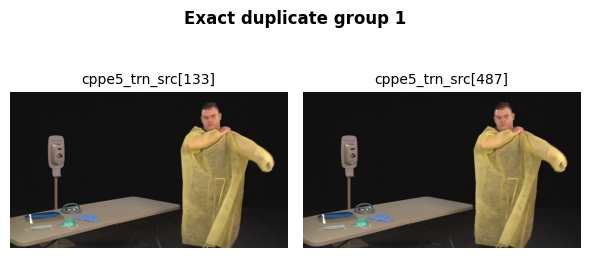

In [9]:
import matplotlib.pyplot as plt
import numpy as np

assert result.sources is not None


def plot_duplicate_group(dataset: object, indices: list[int], source_name: str, group_label: str) -> plt.Figure:
    """Plot a single duplicate group with source[idx] labels."""
    n = len(indices)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    if n == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices, strict=True):
        img = np.array(dataset[idx][0])  # type: ignore[index]
        if img.ndim == 3 and img.shape[0] in (1, 3, 4):
            img = img.transpose(1, 2, 0)
        ax.imshow(img)
        ax.set_title(f"{source_name}[{idx}]", fontsize=10)
        ax.axis("off")
    fig.suptitle(group_label, fontsize=12, fontweight="bold")
    fig.tight_layout()
    return fig


for split_name, split_data in raw.splits.items():
    rd = split_data.redundancy
    if rd.exact_groups:
        print(f"\n{split_name}: {len(rd.exact_groups)} exact duplicate group(s)")
        for i, group in enumerate(rd.exact_groups):
            plot_duplicate_group(result.sources[split_name], group, split_name, f"Exact duplicate group {i + 1}")
    if rd.near_groups:
        print(f"\n{split_name}: {len(rd.near_groups)} near duplicate group(s)")
        for i, group in enumerate(rd.near_groups):
            print(f"  Group {i + 1}: {[f'{split_name}[{idx}]' for idx in group]}")

### Cross-split leakage

Does the same image (or a near-duplicate) appear in multiple splits? Data leakage between
train and test silently inflates evaluation metrics.

When exact duplicates are found we render them side by side so you can visually confirm
the leakage. Near duplicate leakage is printed for reference.

cppe5_trn_src_vs_cppe5_val_src: DATA LEAKAGE DETECTED -- 0 exact, 8 near duplicates
  Near duplicate group 1: ['cppe5_trn_src[59]', 'cppe5_trn_src[81]', 'cppe5_trn_src[176]', 'cppe5_val_src[14]']
  Near duplicate group 2: ['cppe5_trn_src[153]', 'cppe5_trn_src[325]', 'cppe5_trn_src[442]', 'cppe5_val_src[3]']
cppe5_trn_src_vs_cppe5_tst_src: DATA LEAKAGE DETECTED -- 0 exact, 8 near duplicates
  Near duplicate group 1: ['cppe5_trn_src[72]', 'cppe5_trn_src[101]', 'cppe5_tst_src[27]']
  Near duplicate group 2: ['cppe5_trn_src[143]', 'cppe5_trn_src[355]', 'cppe5_trn_src[357]', 'cppe5_tst_src[18]', 'cppe5_tst_src[20]']
cppe5_val_src_vs_cppe5_tst_src: DATA LEAKAGE DETECTED -- 2 exact, 0 near duplicates


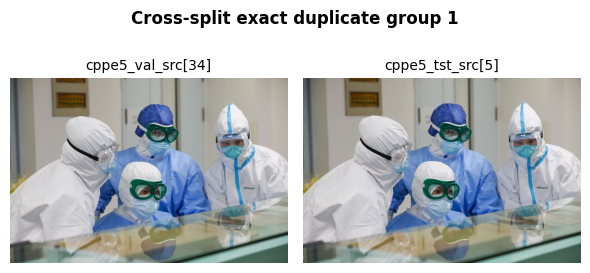

In [10]:
for pair_name, comparison in raw.cross_split.items():
    leakage = comparison.redundancy.duplicate_leakage
    exact_count = leakage.get("exact_count", 0)
    near_count = leakage.get("near_count", 0)
    if exact_count == 0 and near_count == 0:
        print(f"{pair_name}: No cross-split duplicates -- train/test integrity preserved")
        continue

    print(f"{pair_name}: DATA LEAKAGE DETECTED -- {exact_count} exact, {near_count} near duplicates")

    # Render exact duplicate groups — images from both splits side by side
    for i, group in enumerate(leakage.get("exact_groups", [])):
        all_images = []
        all_labels = []
        for split_name, indices in group.items():
            for idx in indices:
                img = np.array(result.sources[split_name][idx][0])
                if img.ndim == 3 and img.shape[0] in (1, 3, 4):
                    img = img.transpose(1, 2, 0)
                all_images.append(img)
                all_labels.append(f"{split_name}[{idx}]")
        if all_images:
            n = len(all_images)
            fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
            if n == 1:
                axes = [axes]
            for ax, img, label in zip(axes, all_images, all_labels, strict=True):
                ax.imshow(img)
                ax.set_title(label, fontsize=10)
                ax.axis("off")
            fig.suptitle(f"Cross-split exact duplicate group {i + 1}", fontsize=12, fontweight="bold")
            fig.tight_layout()

    # Print near duplicate leakage groups (skip rendering)
    for i, group in enumerate(leakage.get("near_groups", [])):
        labels = []
        for split_name, indices in group.items():
            labels.extend(f"{split_name}[{idx}]" for idx in indices)
        if labels:
            print(f"  Near duplicate group {i + 1}: {labels}")

## Step 5: Export results

Export the full result to JSON for integration with automated pipelines or archival.

In [11]:
json_str = result.export(fmt="json")
print(f"JSON output: {len(json_str)} characters")
print(json_str[:500] + "\n...")

JSON output: 1669214 characters
{
  "metadata": {
    "version": "1.0",
    "timestamp": "2026-03-20T18:49:37.721658Z",
    "dataset_id": "cppe5_train,cppe5_train,cppe5_test",
    "label_source": "huggingface",
    "model_id": null,
    "preprocessor_id": null,
    "selection_id": "trn-500,val-50",
    "source_descriptions": [
      "cppe5_trn_src (cppe5_train[trn-500])",
      "cppe5_val_src (cppe5_train[val-50])",
      "cppe5_tst_src (cppe5_test)"
    ],
    "resolved_config": {
      "sources": [
        {
          "name"
...


## Conclusion

In this tutorial you learned how to:

- **Configure** the `data-analysis` workflow with explicit outlier, bias, and divergence parameters
- **Set health thresholds** to control when findings are elevated to warnings
- **Run** the workflow via `run_task()` on a multi-split dataset (CPPE-5 train + test)
- **Read the analysis report** -- a single `result.report()` call for a formatted summary
  covering image quality, redundancy, label health, bias, and cross-split comparisons
- **Explore cross-split data** -- label overlap, proportion differences, parity testing,
  and leakage detection
- **Export** results to JSON for integration with automated pipelines

## What's next

- **Data cleaning** -- Use the `data-cleaning` workflow for actionable outlier and duplicate
  detection with visual inspection via `dataeval-plots`
- **Custom extractors** -- Add an ONNX model configuration to enable embedding-based
  cross-split divergence analysis (distribution shift)
- **Container deployment** -- Mount your dataset and config YAML, then run `dataeval-flow`
  as a container with the same configuration